In [0]:
from pyspark.sql.functions import col, to_timestamp
from pyspark.sql.types import FloatType

# Load the table into a PySpark DataFrame
df = spark.table("dbacademy.labuser11105935_1754645401.renfe_trains")

# Step 1: Filter out rows where price is exactly "price"
df_cleaned = df.filter(col("price") != "price")

# Step 2: Convert price column to float
df_cleaned = df_cleaned.withColumn("price", col("price").cast(FloatType()))

# Step 3: Convert departure and arrival columns to timestamp
df_cleaned = df_cleaned.withColumn("departure", to_timestamp(col("departure"))) \
                       .withColumn("arrival", to_timestamp(col("arrival")))

# Convert PySpark DataFrame to pandas
df_pd = df_cleaned.toPandas()

# Step 4: Preview the cleaned data
df_cleaned.printSchema()
display(df_cleaned)
#display(df_cleaned.limit(5))

company,origin,destination,departure,arrival,vehicle_class,price,fare
renfe,MADRID,SEVILLA,2019-05-07T19:00:00.000Z,2019-05-07T21:38:00.000Z,Preferente,69.4,Promo
renfe,MADRID,SEVILLA,2019-05-07T21:25:00.000Z,2019-05-08T00:10:00.000Z,Turista,43.55,Promo
renfe,MADRID,BARCELONA,2019-05-11T08:30:00.000Z,2019-05-11T11:15:00.000Z,Turista,85.1,Promo
renfe,MADRID,BARCELONA,2019-04-18T14:30:00.000Z,2019-04-18T17:21:00.000Z,Turista,107.7,Flexible
renfe,MADRID,BARCELONA,2019-04-28T16:30:00.000Z,2019-04-28T19:15:00.000Z,Turista,107.7,Flexible
renfe,MADRID,BARCELONA,2019-05-22T14:00:00.000Z,2019-05-22T16:30:00.000Z,Turista,78.8,Promo
renfe,MADRID,BARCELONA,2019-04-17T08:30:00.000Z,2019-04-17T11:15:00.000Z,Turista,75.4,Promo
renfe,MADRID,BARCELONA,2019-05-21T10:30:00.000Z,2019-05-21T13:15:00.000Z,Turista,85.1,Promo
renfe,MADRID,BARCELONA,2019-04-29T20:30:00.000Z,2019-04-29T23:40:00.000Z,Turista,58.15,Promo
renfe,MADRID,SEVILLA,2019-05-04T14:00:00.000Z,2019-05-04T16:32:00.000Z,Turista,76.3,Flexible


In [0]:
from pyspark.sql.functions import mean, stddev, percentile_approx

stats_df = df_cleaned.select(
    mean("price").alias("mean_price"),
    percentile_approx("price", 0.5).alias("median_price"),
    stddev("price").alias("std_dev_price"),
    (percentile_approx("price", 0.75) - percentile_approx("price", 0.25)).alias("IQR")
)

display(stats_df)

mean_price,median_price,std_dev_price,IQR
71.49379980283459,69.4,23.85372104708126,31.699997


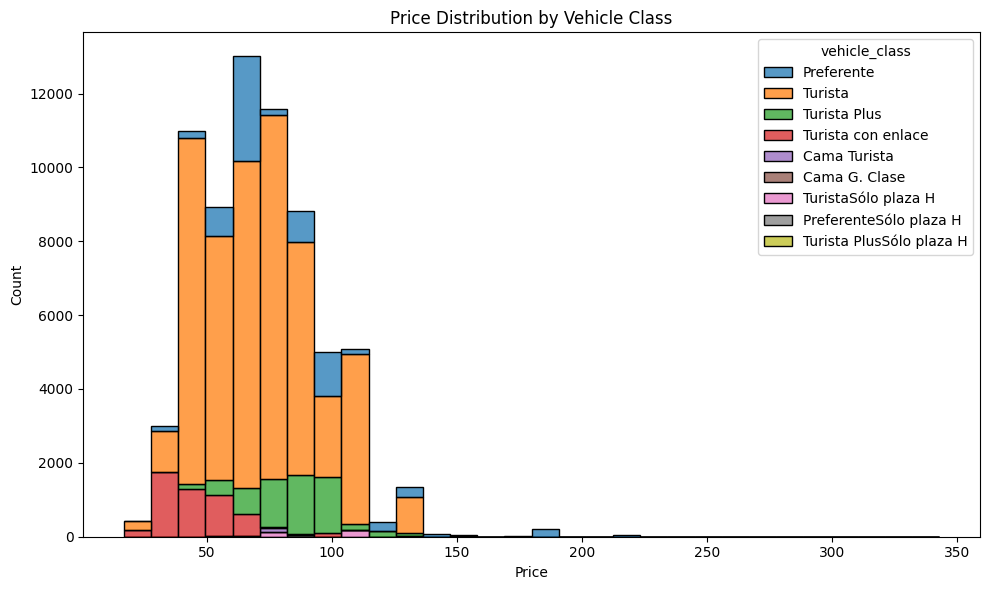

In [0]:
df_pd = df_cleaned.select("price", "vehicle_class").toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=df_pd, x="price", hue="vehicle_class", multiple="stack", bins=30)
plt.title("Price Distribution by Vehicle Class")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


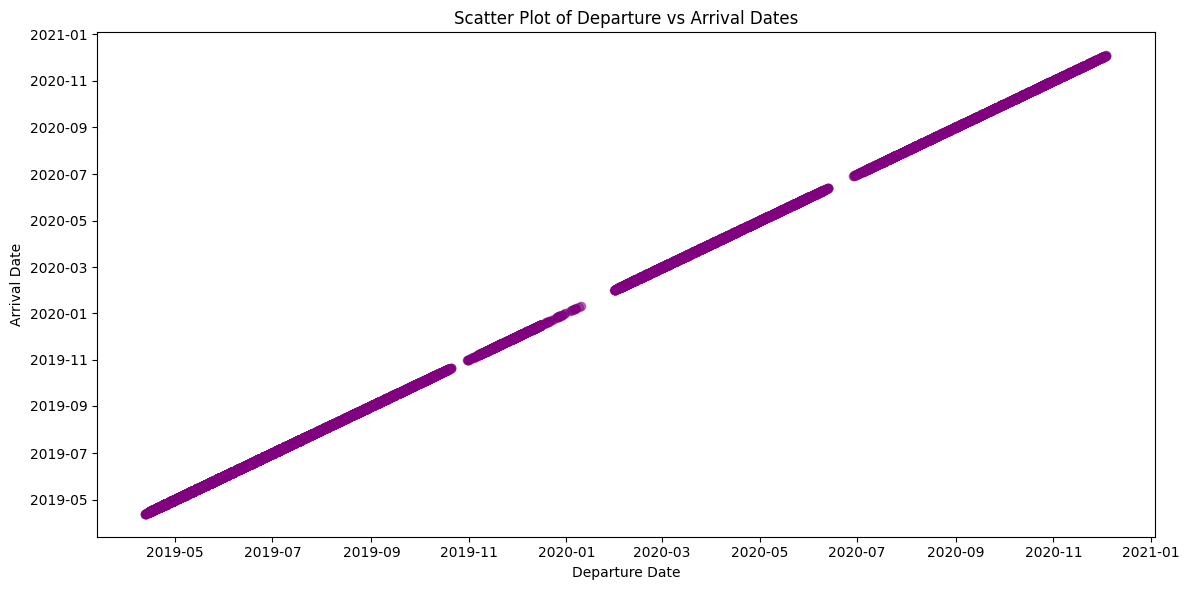

In [0]:
import pandas as pd

df_dates = df_cleaned.select("departure", "arrival").toPandas()
df_dates["departure"] = pd.to_datetime(df_dates["departure"], errors="coerce")
df_dates["arrival"] = pd.to_datetime(df_dates["arrival"], errors="coerce")

plt.figure(figsize=(12, 6))
plt.scatter(df_dates["departure"], df_dates["arrival"], alpha=0.5, color="purple")
plt.title("Scatter Plot of Departure vs Arrival Dates")
plt.xlabel("Departure Date")
plt.ylabel("Arrival Date")
plt.tight_layout()
plt.show()

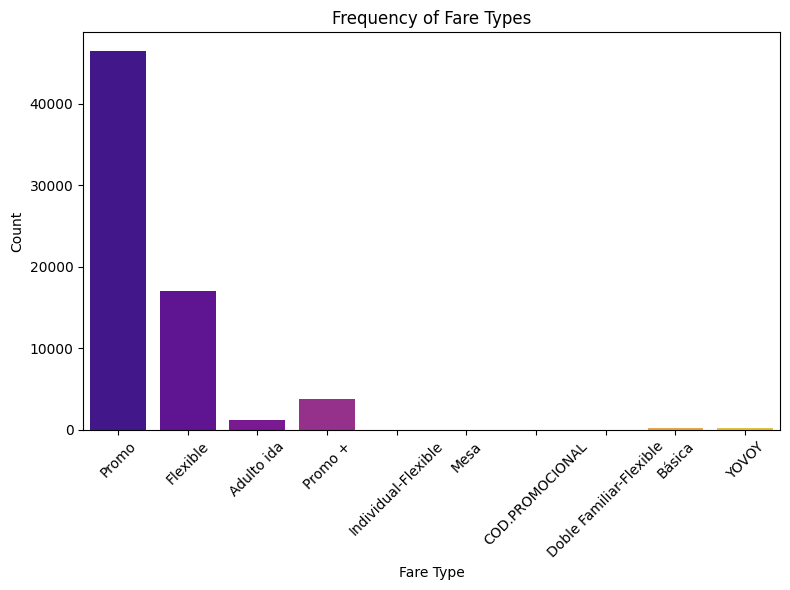

In [0]:
df_fare = df_cleaned.select("fare").toPandas()

plt.figure(figsize=(8, 6))
sns.countplot(data=df_fare, x="fare", palette="plasma")
plt.title("Frequency of Fare Types")
plt.xlabel("Fare Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [0]:
from pyspark.sql.functions import col, sum

# Count missing values per column
missing_counts = df.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]
)
display(missing_counts)

# Inspect rows with any missing values
missing_values = df.filter(
    col("vehicle_class").isNull() | col("price").isNull() | col("fare").isNull()
)
display(missing_values)

company,origin,destination,departure,arrival,vehicle_class,price,fare
0,0,0,0,0,8832,13179,8832


company,origin,destination,departure,arrival,vehicle_class,price,fare
renfe,MADRID,BARCELONA,2019-05-03 18:30:00,2019-05-03 21:20:00,Preferente,null,Promo
renfe,MADRID,BARCELONA,2019-04-23 07:30:00,2019-04-23 10:40:00,Turista,null,Promo
renfe,MADRID,SEVILLA,2019-04-21 21:25:00,2019-04-22 00:10:00,null,null,null
renfe,MADRID,SEVILLA,2019-04-17 09:45:00,2019-04-17 12:27:00,Turista,null,Flexible
renfe,MADRID,SEVILLA,2019-05-03 13:30:00,2019-05-03 16:05:00,Turista,null,Promo
renfe,MADRID,SEVILLA,2019-04-14 09:00:00,2019-04-14 11:38:00,Preferente,null,Promo
renfe,MADRID,SEVILLA,2019-04-23 14:00:00,2019-04-23 16:32:00,Turista,null,Promo
renfe,MADRID,SEVILLA,2019-05-21 08:30:00,2019-05-21 11:14:00,Turista,null,Promo
renfe,MADRID,BARCELONA,2019-04-14 20:30:00,2019-04-14 23:40:00,Preferente,null,Promo
renfe,MADRID,BARCELONA,2019-04-23 20:00:00,2019-04-23 22:30:00,Turista Plus,null,Promo


In [0]:
df_filtered = df_cleaned.dropna(subset=["vehicle_class", "price", "fare"])

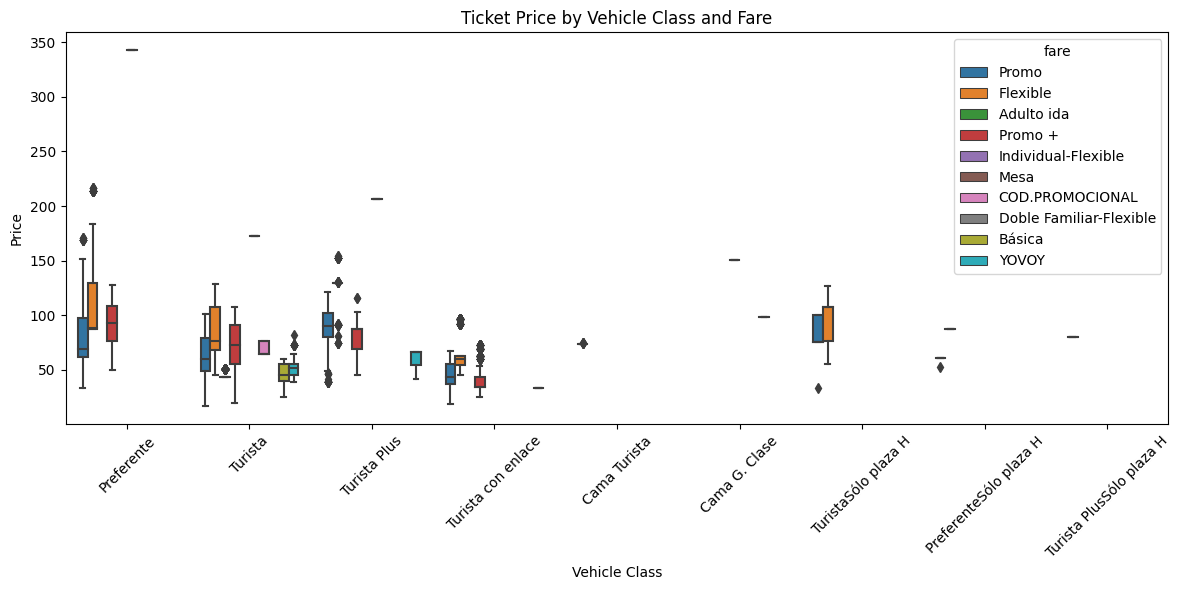

In [0]:
df_pd = df_filtered.select("price", "vehicle_class", "fare").toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pd, x="vehicle_class", y="price", hue="fare")
plt.title("Ticket Price by Vehicle Class and Fare")
plt.xlabel("Vehicle Class")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [0]:
from pyspark.sql.functions import mean, col

# Calculate mean price
mean_price = df_filtered.select(mean("price")).collect()[0][0]

# Fill missing price values
df_filled = df_filtered.fillna({"price": mean_price})

# Count nulls per column after filling
null_counts = df_filled.select([col(c).isNull().cast("int").alias(c) for c in df_filled.columns]).groupBy().sum()
display(null_counts)

sum(company),sum(origin),sum(destination),sum(departure),sum(arrival),sum(vehicle_class),sum(price),sum(fare)
0,0,0,0,0,0,0,0


In [0]:
# Count total rows and distinct rows
total_rows = df_cleaned.count()
distinct_rows = df_cleaned.distinct().count()

import pandas as pd

summary_df = pd.DataFrame({
    "Metric": ["Total rows", "Distinct rows", "Duplicated rows"],
    "Value": [total_rows, distinct_rows, total_rows - distinct_rows]
})

display(summary_df)

Metric,Value
Total rows,68894
Distinct rows,27507
Duplicated rows,41387


In [0]:
df_deduped = df_cleaned.dropDuplicates()

from pyspark.sql.functions import mean, stddev, percentile_approx

stats_df_deduped = df_deduped.select(
    mean("price").alias("mean_price"),
    percentile_approx("price", 0.5).alias("median_price"),
    stddev("price").alias("std_dev_price"),
    (percentile_approx("price", 0.75) - percentile_approx("price", 0.25)).alias("IQR")
)

# Convert stats_df (Pandas) to Spark DataFrame for comparison
stats_df_spark = stats_df

# Combine both DataFrames for comparison
from pyspark.sql.functions import lit

deduped_with_label = stats_df_deduped.withColumn("source", lit("deduped"))
stats_with_label = stats_df_spark.withColumn("source", lit("original"))

comparison_df = deduped_with_label.unionByName(stats_with_label)

display(comparison_df)

mean_price,median_price,std_dev_price,IQR,source
72.73348035648388,69.4,25.68567515719694,34.0,deduped
71.49379980283459,69.4,23.85372104708126,31.699997,original


In [0]:
from pyspark.sql.functions import col, expr

# Assuming df_deduped is your cleaned and de-duplicated Spark DataFrame
Q1 = df_deduped.approxQuantile("price", [0.25], 0.01)[0]
Q3 = df_deduped.approxQuantile("price", [0.75], 0.01)[0]
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_iqr = df_deduped.filter((col("price") < lower_bound) | (col("price") > upper_bound))

display(outliers_iqr)

company,origin,destination,departure,arrival,vehicle_class,price,fare
renfe,MADRID,BARCELONA,2019-04-23T14:30:00.000Z,2019-04-23T17:21:00.000Z,Preferente,181.5,Flexible
renfe,MADRID,BARCELONA,2019-05-17T16:30:00.000Z,2019-05-17T19:15:00.000Z,Preferente,181.5,Flexible
renfe,MADRID,BARCELONA,2019-04-24T16:30:00.000Z,2019-04-24T19:15:00.000Z,Preferente,181.5,Flexible
renfe,MADRID,BARCELONA,2019-05-28T19:30:00.000Z,2019-05-28T22:40:00.000Z,Preferente,181.5,Flexible
renfe,MADRID,BARCELONA,2020-03-06T19:30:00.000Z,2020-03-06T22:40:00.000Z,Preferente,144.95,Promo
renfe,MADRID,BARCELONA,2019-05-26T11:30:00.000Z,2019-05-26T14:40:00.000Z,Preferente,181.5,Flexible
renfe,MADRID,BARCELONA,2019-04-22T14:00:00.000Z,2019-04-22T16:30:00.000Z,Preferente,149.95,Promo
renfe,MADRID,BARCELONA,2019-04-15T11:30:00.000Z,2019-04-15T14:40:00.000Z,Preferente,181.5,Flexible
renfe,MADRID,BARCELONA,2019-05-13T13:25:00.000Z,2019-05-13T16:24:00.000Z,Preferente,181.5,Flexible
renfe,MADRID,BARCELONA,2019-06-10T12:30:00.000Z,2019-06-10T15:30:00.000Z,Preferente,181.5,Flexible


In [0]:
from scipy.stats import zscore
from pyspark.sql.functions import abs

# Convert PySpark DataFrame to Pandas DataFrame
df_pandas = df_deduped.toPandas()

# Calculate Z-scores
df_pandas["z_score"] = zscore(df_pandas["price"].values.flatten())

# Convert Pandas DataFrame back to PySpark DataFrame
df_deduped = spark.createDataFrame(df_pandas)

# Identify outliers with Z-score > 3 or < -3
outliers_z = df_deduped.filter(abs(df_deduped["z_score"]) > 3)

display(outliers_z)

company,origin,destination,departure,arrival,vehicle_class,price,fare,z_score
renfe,MADRID,BARCELONA,2019-04-23T14:30:00.000Z,2019-04-23T17:21:00.000Z,Preferente,181.5,Flexible,4.234597
renfe,MADRID,BARCELONA,2019-05-17T16:30:00.000Z,2019-05-17T19:15:00.000Z,Preferente,181.5,Flexible,4.234597
renfe,MADRID,BARCELONA,2019-04-24T16:30:00.000Z,2019-04-24T19:15:00.000Z,Preferente,181.5,Flexible,4.234597
renfe,MADRID,BARCELONA,2019-05-28T19:30:00.000Z,2019-05-28T22:40:00.000Z,Preferente,181.5,Flexible,4.234597
renfe,MADRID,BARCELONA,2019-05-26T11:30:00.000Z,2019-05-26T14:40:00.000Z,Preferente,181.5,Flexible,4.234597
renfe,MADRID,BARCELONA,2019-04-22T14:00:00.000Z,2019-04-22T16:30:00.000Z,Preferente,149.95,Promo,3.0062637
renfe,MADRID,BARCELONA,2019-04-15T11:30:00.000Z,2019-04-15T14:40:00.000Z,Preferente,181.5,Flexible,4.234597
renfe,MADRID,BARCELONA,2019-05-13T13:25:00.000Z,2019-05-13T16:24:00.000Z,Preferente,181.5,Flexible,4.234597
renfe,MADRID,BARCELONA,2019-06-10T12:30:00.000Z,2019-06-10T15:30:00.000Z,Preferente,181.5,Flexible,4.234597
renfe,MADRID,BARCELONA,2019-05-28T10:30:00.000Z,2019-05-28T13:15:00.000Z,Preferente,181.5,Flexible,4.234597


In [0]:
# Select the same columns from both DataFrames
outliers_iqr_selected = outliers_iqr.select("price", "vehicle_class", "fare")
outliers_z_selected = outliers_z.select("price", "vehicle_class", "fare")

# Combine both sets of outliers
outliers_combined = outliers_iqr_selected.union(outliers_z_selected).dropDuplicates()

# Preview
display(outliers_combined.limit(5))

price,vehicle_class,fare
149.95,Preferente,Promo
143.4,Preferente,Promo
206.8,Turista Plus,Mesa
151.55,Preferente,Promo
144.95,Preferente,Promo


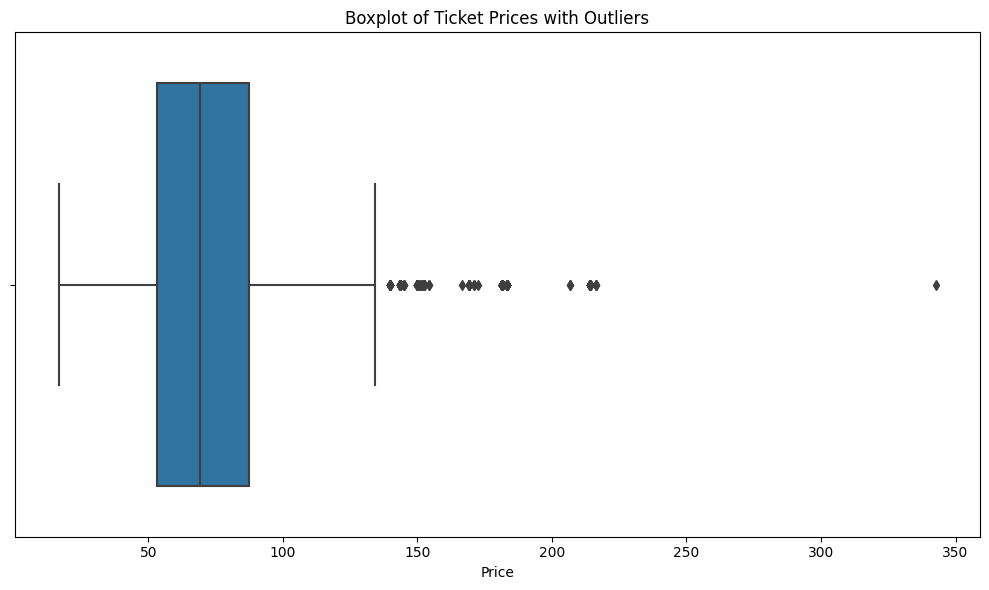

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_deduped.toPandas(), x="price")
plt.title("Boxplot of Ticket Prices with Outliers")
plt.xlabel("Price")
plt.tight_layout()
plt.show()
